# Embeddingi

Embeddingi to wektorowe reprezentacje tekstu, które umożliwiają przeprowadzanie różnych operacji, takich jak wyszukiwanie najbardziej podobnych fragmentów. Dzięki temu można porównywać treści na poziomie ich wektorowych odpowiedników, co pozwala na efektywniejszą analizę i przetwarzanie tekstu.


Istnieje wiele różnych podejść i modeli służących do tworzenia embeddingów. Nie musimy zagłębiać się w niskopoziomowe szczegóły ich działania. Kluczowe z perspektywy budowy systemów RAG jest to, że embedding to wektor o z góry określonej długości, który przechowuje istotne informacje, np.:
- znaczenie tekstu
- kontekst i relacje między słowami

i pozwala wykonać określone operacje, np. semantyczne podobieństwo do innych fragmentów tekstu.

---

W tej części zobaczymy w jaki sposób można wektoryzować tekst, zarówno za pomocą darmowych modeli open source jak również rozwiązań komercyjnych.


## Różnice między modelami
Wybór modelu do embeddingów wpływa na takie czynniki jak:
- jakość embeddingów
- szybkość działania
- koszt wygenerowania embeddingów
- rozmiar wektorów


Im większy rozmiar embeddingu tym lepszej dokładności możemy się spodziewać (do pewnego momentu), ale wiąże się to również z większym obciążeniem pod względem złożoności obliczeniowej czy objętości danych w bazie.

In [ ]:
import os
import numpy as np
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEmbeddings

In [ ]:
load_dotenv()

In [ ]:
text = """Sztuczna inteligencja – rewolucja technologiczna naszych czasów

Sztuczna inteligencja (SI) to jedna z najszybciej rozwijających się dziedzin technologii, która znacząco wpływa na różne aspekty naszego życia. Dzięki wykorzystaniu zaawansowanych algorytmów i mocy obliczeniowej komputerów, SI potrafi analizować ogromne ilości danych, uczyć się na ich podstawie i podejmować decyzje, które jeszcze niedawno były domeną wyłącznie ludzi.
"""

print(text)

## HuggingFace

HuggingFace jest platformą, na której udostępniane są modele, np. takie do tworzenia embeddingów, które możemy pobrać i zintegrować z naszym kodem. W kontekście modeli embeddingowych oraz ich zastosowania w LangChain będziemy używać klasy `HuggingFaceEmbeddings`.

---

Repozytoria na HuggingFace mają postać `<nazwa_organizacji>/<nazwa_modelu>`. Jedną z organizacji, która udostępnia wiele modeli do embeddingów jest `sentence-transformers`.

---

Nazwa modelu składa się zwykle z kilku członów. W przypadku `sentence-transformers` najczęściej są to:
- prefix (np. `all`, co oznacza, że model jest uniwersalny i został wytrenowany na szerokim zakresie różnych tekstów)
- obsługiwany język – jeśli go nie ma, to domyślnie jest to języka angielski. Jeśli model obsługuje wiele języków, to w jego nazwie znajduje się "multilingual"
- architektura (określa bazowy model językowy, o który oparte jest tworzenie embeddingów, np. `MiniLM`, `mpnet`)
- rozmiar modelu – ile warstw transformerów posiada (np. `L6` – 6 warstw, `base` – pełnowymiarowy model, ok. 12 warstw, `large` – duży model, około 24 warstwy)
- wersja (np. v2)

---

Istnieje wiele modeli do tworzenia embeddingów. Poniżej znajduje się przegląd tylko niektórych z nich.

### `sentence-transformers/all-mpnet-base-v2`

https://huggingface.co/sentence-transformers/all-mpnet-base-v2

Zwraca wektor o długości 768, który jest znormalizowany.

In [ ]:
model_name = "sentence-transformers/all-mpnet-base-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    # model_kwargs={'token': os.environ["HUGGINGFACE_TOKEN"]}
)

In [ ]:
embedding = embeddings.embed_query(text)
embedding

In [ ]:
len(embedding)

### `sentence-transformers/paraphrase-multilingual-mpnet-base-v2`

https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2

Zwraca wektor o długości 768, który nie jest znormalizowany.

In [ ]:
model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    # model_kwargs={'token': os.environ["HUGGINGFACE_TOKEN"]}
)

In [ ]:
embedding = embeddings.embed_query(text)

In [ ]:
len(embedding)

### `sdadas/st-polish-paraphrase-from-distilroberta`

https://huggingface.co/sdadas/st-polish-paraphrase-from-distilroberta

Retrieval na podstawie embeddingów w języku polskim często nie daje tak dobrych wyników jak ten na tekście angielskim, nawet kiedy używamy modeli multilingual. Ten model jednak sprawdza się całkiem nieźle w obsłudze języka polskiego.

In [ ]:
model_name = "sdadas/st-polish-paraphrase-from-distilroberta"

In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    # model_kwargs={'token': os.environ["HUGGINGFACE_TOKEN"]}
)

In [ ]:
embedding = embeddings.embed_query(text)

In [ ]:
len(embedding)

## OpenAI

OpenAI oferuje 3 modele do tworzenia embeddingów:
- `text-embedding-3-small`
- `text-embedding-3-large`
- `text-embedding-ada-002`


Cena za utworzenie embeddingów jest rzędu około $0.10 za 1M tokenów embedowanego tekstu.

https://platform.openai.com/docs/pricing#embeddings

In [ ]:
from langchain_openai.embeddings import OpenAIEmbeddings

In [ ]:
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")

In [ ]:
embedding = embeddings.embed_query(text)
embedding

In [ ]:
len(embedding)

**Tworzenie embeddingów wielu tekstów**

In [ ]:
texts = ["Pierwszy tekst", "Drugi tekst", "Trzeci tekst"]

embedding_vectors = embeddings.embed_documents(texts)

In [ ]:
print(len(embedding_vectors), "\n\n")

for vector in embedding_vectors:
    print(len(vector))

## Podobieństwo między wektorami

Celem wektoryzacji tekstu w kontekście tworzenia systemu RAG jest umożliwienie wyszukiwania najbardziej adekwatnych fragmentów dokumentów względem promptu, który wpisał użytkownik. W tym celu niezbędne będzie korzystanie z metryk podobieństwa wektorów. 

Istnieją różne miary odległości wektorów, ale najczęściej stosowaną jest podobieństwo cosinusowe. Opiera się ona o cosinus kąta między wektorami w przestrzeni n-wymiarowej.

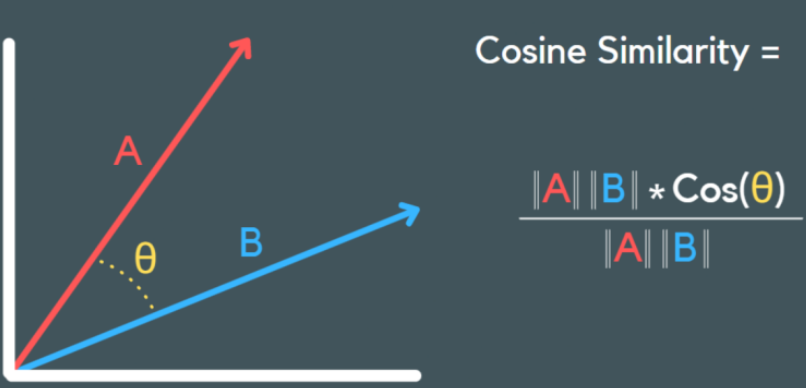

Porównywać podobieństwo wektorów powinniśmy tylko wtedy gdy zostały stworzone za pomocą tego samego modelu.

In [ ]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [ ]:
base = "Muszę zrobić zakupy w supermarkecie"

In [ ]:
sentences = [    
    "Dziś po pracy idę do sklepu na zakupy",
    "Planuję kupić warzywa i owoce",
    "Wczoraj byłem na siłowni",
    "Zamówiłem pizzę na kolację"
]

### `sentence-transformers/all-mpnet-base-v2`

In [ ]:
model_name = "sentence-transformers/all-mpnet-base-v2"
embeddings = HuggingFaceEmbeddings(model_name=model_name)

base_vector = embeddings.embed_query(base)
sentences_vectors = embeddings.embed_documents(sentences)

In [ ]:
similarities = []

for vector, sentence in zip(sentences_vectors, sentences):
    similarities.append(cosine_similarity(vector, base_vector))


print(base, "\n---")

sorted(zip(similarities, sentences), reverse=True)

### `paraphrase-multilingual-mpnet-base-v2`

In [ ]:
model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
embeddings = HuggingFaceEmbeddings(model_name=model_name)

base_vector = embeddings.embed_query(base)
sentences_vectors = embeddings.embed_documents(sentences)

In [ ]:
similarities = []

for vector, sentence in zip(sentences_vectors, sentences):
    similarities.append(cosine_similarity(vector, base_vector))


print(base, "\n---")

sorted(zip(similarities, sentences), reverse=True)

### `text-embedding-ada-002`

In [ ]:
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")

base_vector = embeddings.embed_query(base)
sentences_vectors = embeddings.embed_documents(sentences)

In [ ]:
similarities = []

for vector, sentence in zip(sentences_vectors, sentences):
    similarities.append(cosine_similarity(vector, base_vector))


print(base, "\n---")

sorted(zip(similarities, sentences), reverse=True)

> **ZADANIA**